In [2]:
!pip install torch torchvision pandas scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data_path='/content/diabetes.csv'
df=pd.read_csv(data_path)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
X=df.drop('Outcome',axis=1).values
y=df['Outcome'].values

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [9]:
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [10]:
class FeedForwardNN(nn.Module):
  def __init__(self, input_size):
    super(FeedForwardNN, self).__init__()
    self.fc1 = nn.Linear(input_size, 64)
    self.fc2 = nn.Linear(64,32)
    self.fc3 = nn.Linear(32,1)

  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

input_size = X_train_tensor.shape[1]
model = FeedForwardNN(input_size)

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
num_epochs =50
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for inputs, labels in train_loader:
    optimiser.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs,labels)
    loss.backward()
    optimiser.step()
    running_loss += loss.item() * inputs.size(0)

  epoch_loss = running_loss/ len(train_dataset)
  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 10/50, Loss: 0.4372
Epoch 20/50, Loss: 0.4163
Epoch 30/50, Loss: 0.3984
Epoch 40/50, Loss: 0.3853
Epoch 50/50, Loss: 0.3690



Test Accuracy: 73.38%


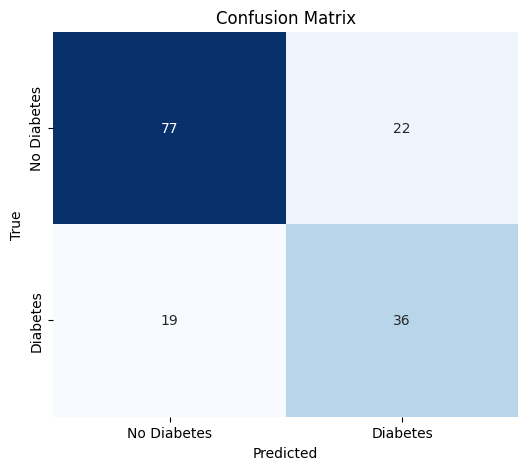


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.78      0.79        99
    Diabetes       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



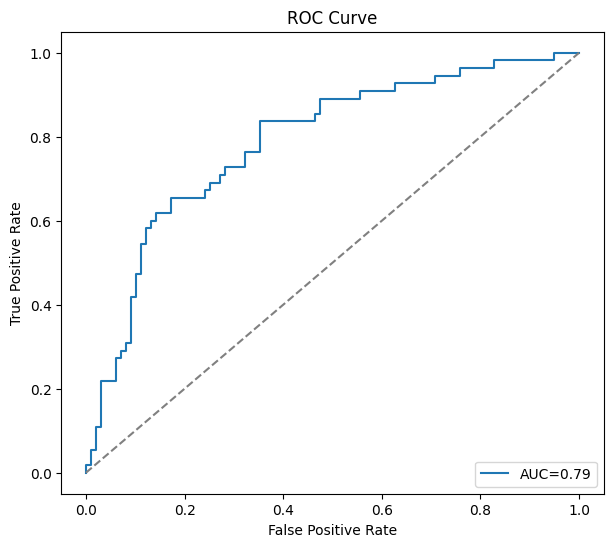


✅ Model and scaler saved together as diabetes_model_with_scaler.pth

Sample prediction:0(probability:0.36)


In [13]:
model.eval()
y_true = []
y_pred = []
y_scores = []

with torch.no_grad():
  for inputs,labels in test_loader:
    outputs = model(inputs)
    probs = torch.sigmoid(outputs)
    predicted = (probs > 0.5).float()
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())
    y_scores.extend(probs.cpu().numpy())

y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()
y_scores = np.array(y_scores).flatten()

accuracy = (y_true == y_pred).mean()*100
print(f"\nTest Accuracy: {accuracy:.2f}%")

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,
            xticklabels=["No Diabetes","Diabetes"],
            yticklabels=["No Diabetes","Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true,y_pred,target_names=["No Diabetes","Diabetes"]))

fpr,tpr,thresholds=roc_curve(y_true,y_scores)
auc_score=roc_auc_score(y_true,y_scores)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,label=f"AUC={auc_score:.2f}")
plt.plot([0,1],[0,1],linestyle="--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

torch.save({
    'model_state_dict':model.state_dict(),
    'scaler':scaler
},"diabetes_model_with_scaler.pth")
print("\n✅ Model and scaler saved together as diabetes_model_with_scaler.pth")


loaded_model=FeedForwardNN(input_size)
checkpoint=torch.load("diabetes_model_with_scaler.pth",map_location=torch.device('cpu'),weights_only=False)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
loaded_scaler=checkpoint['scaler']

sample_raw=X_test[0].reshape(1,-1)
sample_scaled=loaded_scaler.transform(sample_raw)
sample_tensor=torch.tensor(sample_scaled,dtype=torch.float32)

with torch.no_grad():
  output=loaded_model(sample_tensor)
  prob=torch.sigmoid(output).item()
  pred=1 if prob>0.5 else 0

print(f"\nSample prediction:{pred}(probability:{prob:.2f})")

In [14]:
from google.colab import files
files.download("/content/diabetes_model_with_scaler.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
!pip install torch torchvision gradio scikit-learn

In [16]:
import torch
import torch.nn as nn
import gradio as gr

In [17]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [18]:
input_size = 8
model = FeedForwardNN(input_size)

checkpoint = torch.load("/content/diabetes_model_with_scaler.pth", map_location=torch.device('cpu'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
scaler = checkpoint['scaler']

In [19]:
def predict_diabetes(Pregnancies, Glucose, BloodPressure, SkinThickness,
                     Insulin, BMI, DPF, Age):
    import numpy as np
    features = np.array([[Pregnancies, Glucose, BloodPressure, SkinThickness,
                          Insulin, BMI, DPF, Age]])
    features_scaled = scaler.transform(features)
    sample = torch.tensor(features_scaled, dtype=torch.float32)

    with torch.no_grad():
        output = model(sample)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0

    result = "Diabetic" if pred == 1 else "Not Diabetic"
    return f"Prediction: {result} (Probability: {prob:.2f})"

In [20]:
inputs = [
    gr.Number(label="Pregnancies"),
    gr.Number(label="Glucose"),
    gr.Number(label="BloodPressure"),
    gr.Number(label="SkinThickness"),
    gr.Number(label="Insulin"),
    gr.Number(label="BMI"),
    gr.Number(label="DiabetesPedigreeFunction"),
    gr.Number(label="Age"),
]

iface = gr.Interface(
    fn=predict_diabetes,
    inputs=inputs,
    outputs="text",
    title="Diabetes Prediction",
    description="Enter patient details and predict diabetes risk."
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://72e61a560e94e2f458.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
